# ResNET Evaluation

## Imports

In [11]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import torch
from torch import nn
from torchvision import models
from src.data import createDataset, createDataLoader, test_transforms

torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Test Dataset and Dataloader

In [12]:
test_dataset = createDataset(
    path='../dataset/test',
    transform=test_transforms
)

test_dataloader = createDataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

## ResNET Frozen - Evaluation

In [13]:
frozen_model = models.resnet18(weights=None)

frozen_model.fc = nn.Linear(frozen_model.fc.in_features, 4)

frozen_model.load_state_dict(
    torch.load('../models/ResNET_Frozen.pt')
)

frozen_model = frozen_model.to(device)

ResNET (Frozen) - Metrics :-
Accuracy: 80.6875%
Precision: 81.6721%
Recall: 80.6875%


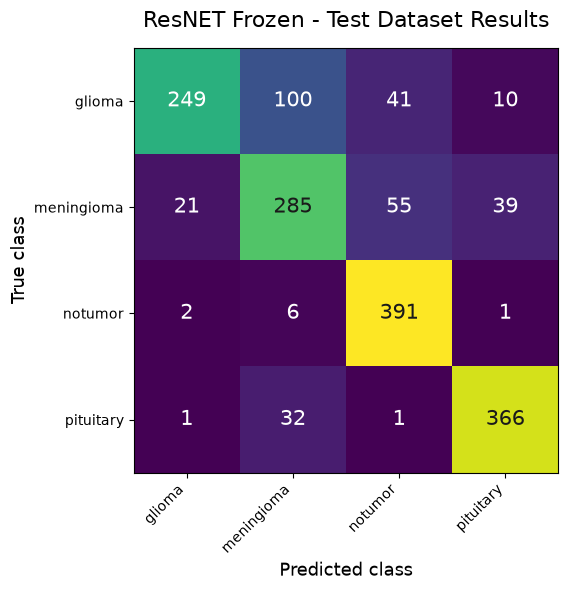

In [14]:
from src.evaluation import evaluateModel, plot_confusion_matrix

frozen_results, frozen_cm = evaluateModel(
    model=frozen_model,
    dataloader=test_dataloader,
    device=device
)

print(f"ResNET (Frozen) - Metrics :-")
print(f"Accuracy: {frozen_results['accuracy']*100:.4f}%")
print(f"Precision: {frozen_results['precision']*100:.4f}%")
print(f"Recall: {frozen_results['recall']*100:.4f}%")

plot_confusion_matrix(frozen_cm, test_dataset.classes, "ResNET Frozen - Test Dataset Results")

## ResNET Frozen + PartialFT - Evaluation

In [15]:
partialFT_model = models.resnet18(weights=None)

partialFT_model.fc = nn.Linear(partialFT_model.fc.in_features, 4)

partialFT_model.load_state_dict(
    torch.load('../models/ResNET_Frozen_PartialFT.pt')
)

partialFT_model = partialFT_model.to(device)

ResNET (Frozen + PartialFT) - Metrics :-
Accuracy: 91.6875%
Precision: 92.1325%
Recall: 91.6875%


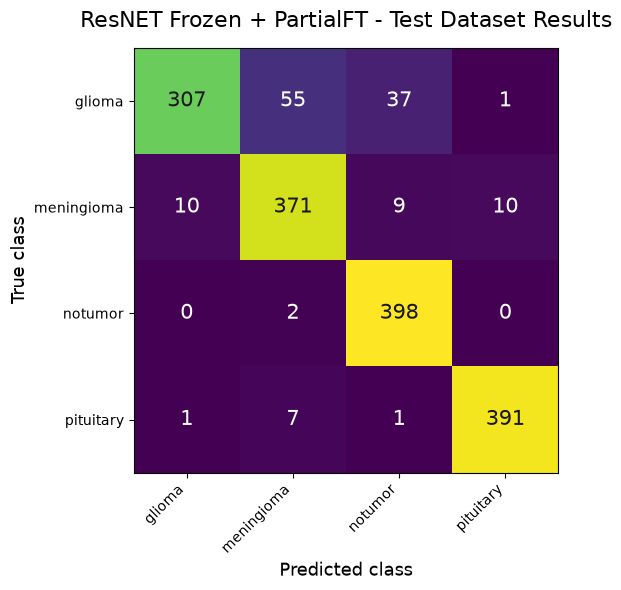

In [16]:
partialFT_results, partialFT_cm = evaluateModel(
    model=partialFT_model,
    dataloader=test_dataloader,
    device=device
)

print(f"ResNET (Frozen + PartialFT) - Metrics :-")
print(f"Accuracy: {partialFT_results['accuracy']*100:.4f}%")
print(f"Precision: {partialFT_results['precision']*100:.4f}%")
print(f"Recall: {partialFT_results['recall']*100:.4f}%")

plot_confusion_matrix(partialFT_cm, test_dataset.classes, "ResNET Frozen + PartialFT - Test Dataset Results")

## ResNET Frozen + CompleteFT - Evaluation

In [17]:
completeFT_model = models.resnet18(weights=None)

completeFT_model.fc = nn.Linear(completeFT_model.fc.in_features, 4)

completeFT_model.load_state_dict(
    torch.load('../models/ResNET_Frozen_FT.pt')
)

completeFT_model = completeFT_model.to(device)

ResNET (Frozen + CompleteFT) - Metrics :-
Accuracy: 93.1875%
Precision: 93.5686%
Recall: 93.1875%


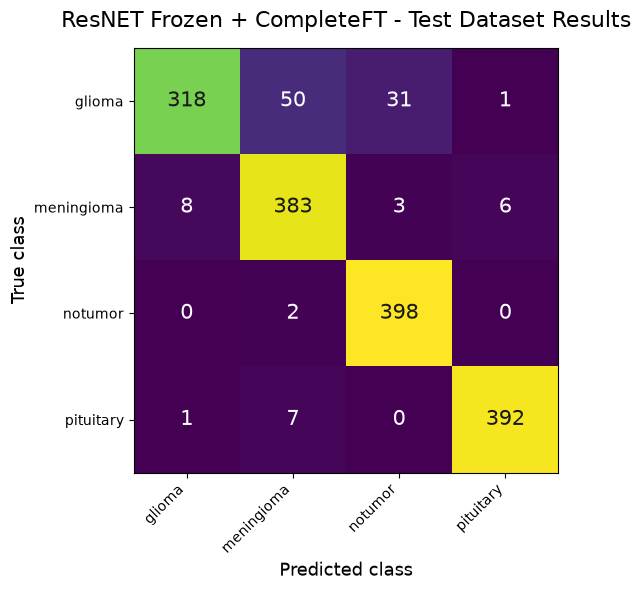

In [18]:
completeFT_results, completeFT_cm = evaluateModel(
    model=completeFT_model,
    dataloader=test_dataloader,
    device=device
)

print(f"ResNET (Frozen + CompleteFT) - Metrics :-")
print(f"Accuracy: {completeFT_results['accuracy']*100:.4f}%")
print(f"Precision: {completeFT_results['precision']*100:.4f}%")
print(f"Recall: {completeFT_results['recall']*100:.4f}%")

plot_confusion_matrix(completeFT_cm, test_dataset.classes, "ResNET Frozen + CompleteFT - Test Dataset Results")

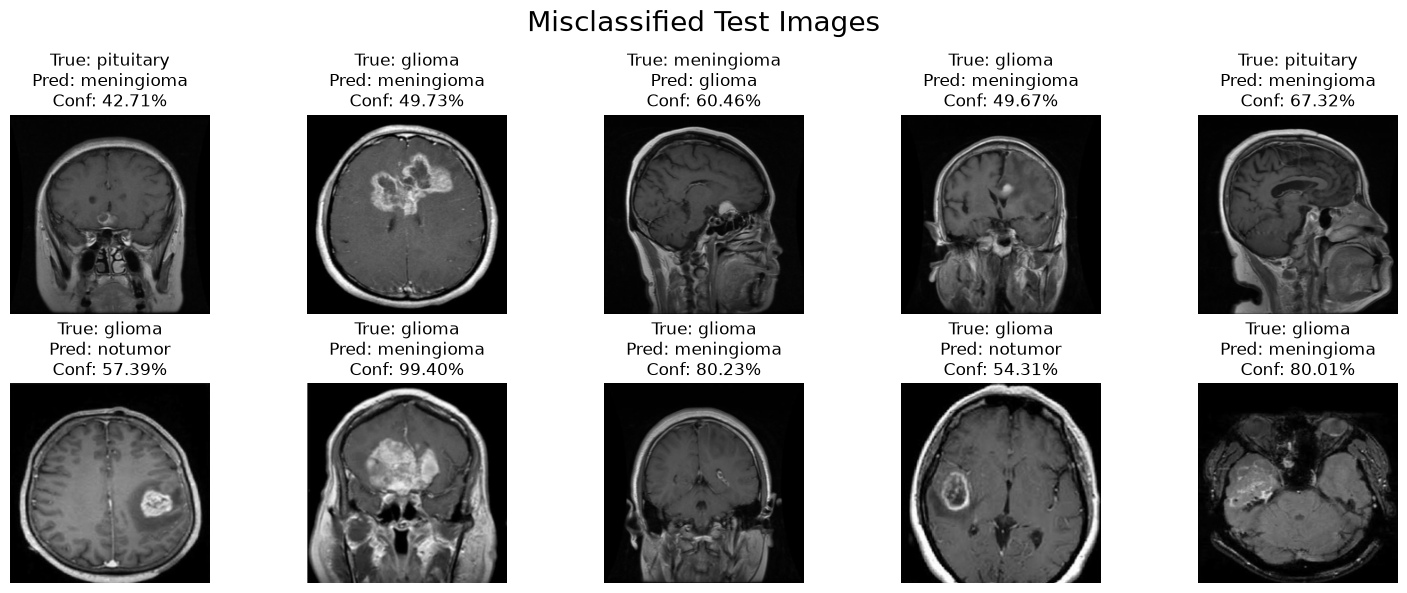

In [19]:
from src.evaluation import get_misclassified_images, show_misclassified_images

misclassified = []
misclassified = get_misclassified_images(
    model=completeFT_model,
    dataloader=test_dataloader,
    dataset=test_dataset,
    device=device,
    class_names=test_dataset.classes
)

show_misclassified_images(misclassified=misclassified, n=10)
